In [ ]:
# Análisis Exploratorio de Datos (EDA)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargamos el dataset procesado desde la etapa anterior
df = pd.read_json("../data/processed/streaming_users_processed.json")

# Configuración visual global para todos los gráficos y que no quede con muchos colores sin sentido
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13

print("Shape del dataset:", df.shape)
df.head()

Shape del dataset: (7067, 9)


,user_id,age,subscription_plan,monthly_watch_time_mins,country,favorite_genre,last_login_date,customer_support_tickets,days_since_last_login
0,10000,39,estandar,805.8,brasil,crimen,1741046400000,99,479
1,10001,37,estandar,1173.4,colombia,crimen,1554163200000,2,2642
2,10002,28,basico,401.0,colombia,crimen,1523577600000,0,2996
3,10003,43,basico,62.4,uruguay,thriller,1612051200000,0,1972
4,10004,51,basico,477.8,peru,thriller,1601424000000,1,2095


## Preguntas de análisis

Este EDA busca responder cinco preguntas concretas sobre el comportamiento
de los usuarios de la plataforma de streaming:

1. **¿Cómo se distribuye la edad de los usuarios?**
   Permite entender si la base de usuarios es joven, adulta o mixta,
   lo que condiciona cualquier decisión de segmentación posterior.

2. **¿Qué plan de suscripción predomina en la plataforma?**
   Identificar el plan más frecuente es la base para comparaciones
   por segmento en etapas posteriores.

3. **¿El plan de suscripción se refleja en el consumo real de la plataforma?**
   Analizamos si los usuarios premium efectivamente consumen más minutos
   que los de planes básico o estándar.

4. **¿Los usuarios con más tickets de soporte llevan más días sin ingresar?**
   Exploramos si una experiencia técnica negativa se asocia con el
   alejamiento del usuario de la plataforma.

5. **¿Qué relaciones existen entre las variables numéricas del dataset?**
   Un análisis de correlación entre edad, minutos, tickets y días sin
   login permite identificar patrones globales y orienta las decisiones de PCA.

In [ ]:
# Crear grupos de edades
bins = [0, 17, 25, 35, 45, 60, 100]
labels = ["<18", "18-25", "26-35", "36-45", "46-60", ">60"]

df["grupo_edad"] = pd.cut(df["age"], bins=bins, labels=labels)

# Crear tabla
tabla_edades = (
    df["grupo_edad"]
    .value_counts()
    .sort_index()
    .reset_index()
)

tabla_edades = pd.DataFrame({
    "Cantidad": df["grupo_edad"].value_counts().sort_index(),
    "Porcentaje (%)": round(df["grupo_edad"].value_counts(normalize=True).sort_index() * 100, 2)
})

tabla_edades

,Cantidad,Porcentaje (%)
grupo_edad,,
<18,678,9.59
18-25,1148,16.24
26-35,2199,31.12
36-45,1947,27.55
46-60,1006,14.24
>60,89,1.26


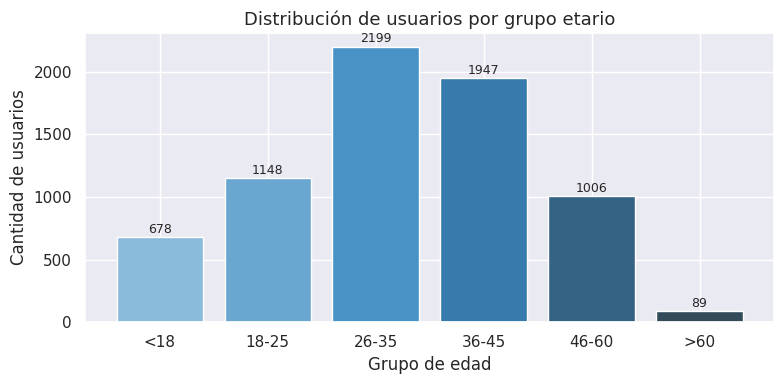

In [ ]:
# VIZ 1 — Distribución de edad Usamos el grupo_edad que ya creamos

conteo = df["grupo_edad"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))

# Barras por grupo etario con color degradado para leer jerarquía
bars = ax.bar(
    conteo.index,
    conteo.values,
    color=sns.color_palette("Blues_d", len(conteo)),
    edgecolor="white"
)

# Etiqueta de cantidad encima de cada barra
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,   # centro horizontal de la barra
        bar.get_height() + 10,                # levemente por encima
        str(int(bar.get_height())),
        ha="center", va="bottom", fontsize=9
    )

ax.set_title("Distribución de usuarios por grupo etario")
ax.set_xlabel("Grupo de edad")
ax.set_ylabel("Cantidad de usuarios")
plt.tight_layout()
plt.show()

La distribución de edades muestra que la plataforma posee una base de usuarios (principalmente joven/adulta/mixta). La mayor concentración de usuarios se encuentra entre 26 y 35 años, mientras que existen pocos usuarios en los extremos de edad. El boxplot permite identificar si existen valores atípicos, aunque en este caso corresponden a edades válidas. Esta información resulta útil para orientar estrategias de segmentación y personalización del contenido.


In [ ]:
# Tabla de frecuencias
tabla_planes = pd.DataFrame({
    "Cantidad": df["subscription_plan"].value_counts(),
    "Porcentaje (%)": round(df["subscription_plan"].value_counts(normalize=True) * 100, 2)
})

tabla_planes.index.name = "Plan de suscripción"
tabla_planes

,Cantidad,Porcentaje (%)
Plan de suscripción,,
basico,3155,44.64
estandar,2502,35.40
premium,1410,19.95


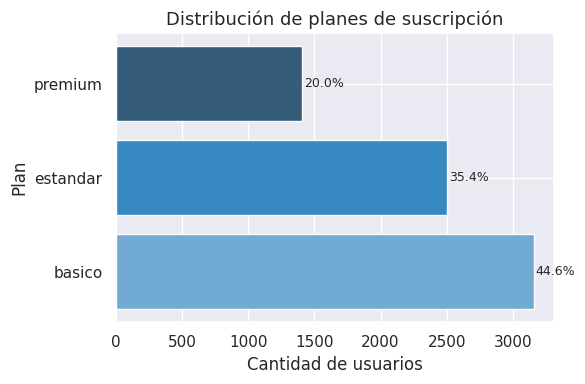

In [ ]:
# VIZ 2 — Distribución de planes
conteo_planes = df["subscription_plan"].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.barh(
    conteo_planes.index,
    conteo_planes.values,
    color=sns.color_palette("Blues_d", len(conteo_planes)),
    edgecolor="white"
)

# Porcentaje al final de cada barra
total = conteo_planes.sum()
for bar, val in zip(bars, conteo_planes.values):
    ax.text(
        bar.get_width() + 15,                  # a la derecha de la barra
        bar.get_y() + bar.get_height() / 2,    # centrado verticalmente
        f"{val / total * 100:.1f}%",
        va="center", fontsize=9
    )

ax.set_title("Distribución de planes de suscripción")
ax.set_xlabel("Cantidad de usuarios")
ax.set_ylabel("Plan")
plt.tight_layout()
plt.show()

El análisis muestra que el plan basico es el más utilizado por los usuarios, representando aproximadamente el 44% del total. Este resultado indica que la mayor parte de la base de clientes pertenece a este segmento, por lo que resulta un punto de referencia adecuado para realizar comparaciones con los demás planes de suscripción en análisis posteriores.



In [ ]:
# Estadísticas por plan
resumen = (
    df.groupby("subscription_plan")["monthly_watch_time_mins"]
    .agg(
        Cantidad="count",
        Promedio="mean",
        Mediana="median",
        Minimo="min",
        Maximo="max"
    )
    .round(2)
)

resumen

,Cantidad,Promedio,Mediana,Minimo,Maximo
subscription_plan,,,,,
basico,3155,600.00,556.2,0.0,4142.6
estandar,2502,869.08,838.5,0.0,4193.7
premium,1410,1142.03,1128.4,66.1,4188.7


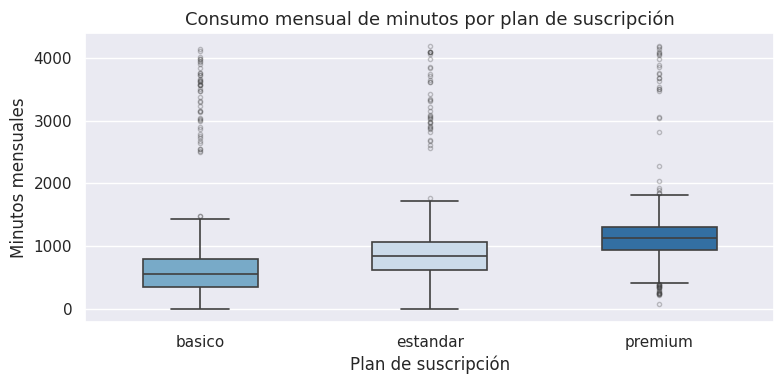

In [ ]:
# VIZ 3 — Consumo por plan Boxplot: muestra mediana, dispersión y outliers por plan

orden = ["basico", "estandar", "premium"]

fig, ax = plt.subplots(figsize=(8, 4))

sns.boxplot(
    data=df,
    x="subscription_plan",
    y="monthly_watch_time_mins",
    order=orden,
    palette="Blues",
    hue="subscription_plan",
    legend=False,
    width=0.5,
    linewidth=1.2,
    flierprops=dict(marker="o", markersize=3, alpha=0.3),  # outliers pequeños
    ax=ax
)

ax.set_title("Consumo mensual de minutos por plan de suscripción")
ax.set_xlabel("Plan de suscripción")
ax.set_ylabel("Minutos mensuales")
plt.tight_layout()
plt.show()

Se observa que el consumo promedio de minutos aumenta conforme se pasa de un plan básico a uno estándar y luego a uno premium. Esto sugiere que los usuarios con planes de mayor categoría tienden a utilizar más la plataforma, lo que es consistente con la expectativa de que quienes pagan por un servicio más completo hacen un uso más intensivo del mismo.

In [ ]:
# Correlación
correlacion = df["customer_support_tickets"].corr(df["days_since_last_login"])

print(f"Correlación de Pearson: {correlacion:.3f}")

tabla = (
    df.groupby("customer_support_tickets")["days_since_last_login"]
    .agg(
        Cantidad_Usuarios="count",
        Promedio_Dias="mean",
        Mediana="median"
    )
    .round(2)
)

tabla



Correlación de Pearson: 0.004


,Cantidad_Usuarios,Promedio_Dias,Mediana
customer_support_tickets,,,
0,3290,1610.46,1605.0
1,2590,1606.93,1589.5
2,858,1592.31,1564.0
3,200,1692.54,1692.0
4,57,1623.26,1472.0
5,12,1643.17,1680.0
99,31,1733.74,1857.0
150,29,1585.28,1480.0


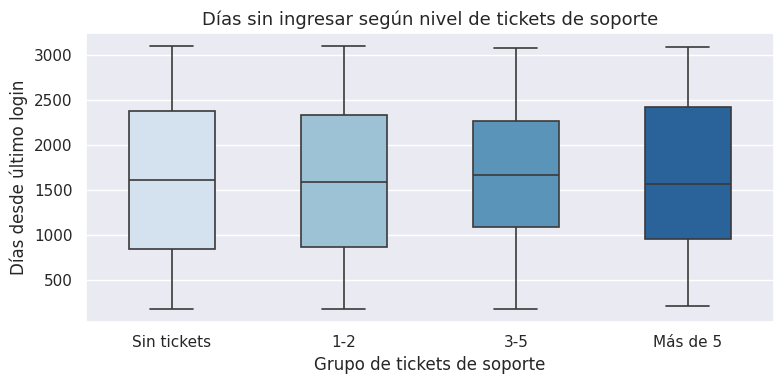

grupo_tickets
Sin tickets    1605.0
1-2            1584.5
3-5            1665.0
Más de 5       1569.5
Name: days_since_last_login, dtype: float64


In [ ]:
# VIZ 4 — Días sin login según nivel de tickets de soporte
# Agrupamos tickets en categorías para evitar el problema del
# eje estirado por outliers extremos (99, 150 tickets)

# Creamos grupos de tickets con rangos con sentido
df["grupo_tickets"] = pd.cut(
    df["customer_support_tickets"],
    bins=[-1, 0, 2, 5, 150],                          # rangos definidos por la distribución real
    labels=["Sin tickets", "1-2", "3-5", "Más de 5"]  # etiquetas legibles
)

fig, ax = plt.subplots(figsize=(8, 4))

sns.boxplot(
    data=df,
    x="grupo_tickets",
    y="days_since_last_login",
    palette="Blues",
    hue="grupo_tickets",
    legend=False,
    width=0.5,
    linewidth=1.2,
    flierprops=dict(marker="o", markersize=3, alpha=0.3),
    ax=ax
)

ax.set_title("Días sin ingresar según nivel de tickets de soporte")
ax.set_xlabel("Grupo de tickets de soporte")
ax.set_ylabel("Días desde último login")
plt.tight_layout()
plt.show()

# Tabla de medianas por grupo para complementar la lectura
print(df.groupby("grupo_tickets", observed=False)["days_since_last_login"].median().round(1))

Se analizó la relación entre la cantidad de tickets de soporte y los días transcurridos desde el último ingreso. El coeficiente de correlación obtenido fue 0,004, lo que indica una relación nula entre ambas variables.

In [ ]:
variables = df[[
    "age",
    "monthly_watch_time_mins",
    "customer_support_tickets",
    "days_since_last_login"
]]

# Calcular matriz de correlación
correlacion = variables.corr()

correlacion

,age,monthly_watch_time_mins,customer_support_tickets,days_since_last_login
age,1.000000,0.004187,0.002704,-0.013016
monthly_watch_time_mins,0.004187,1.000000,-0.011560,-0.003475
customer_support_tickets,0.002704,-0.011560,1.000000,0.004200
days_since_last_login,-0.013016,-0.003475,0.004200,1.000000


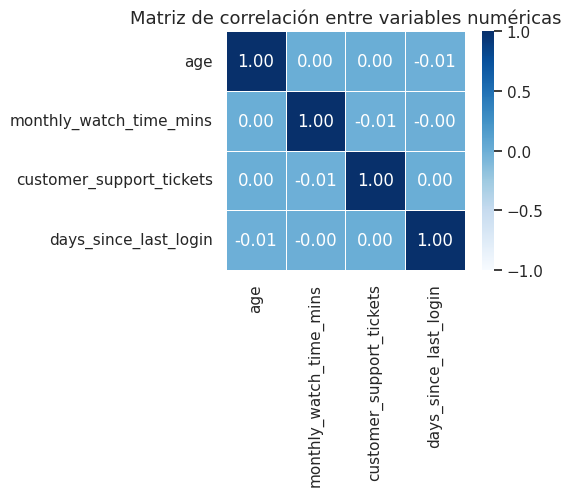

In [ ]:
# VIZ 5 — Heatmap de correlación (complementa celda 10)

variables = df[[
    "age",
    "monthly_watch_time_mins",
    "customer_support_tickets",
    "days_since_last_login"
]]

matriz_corr = variables.corr()

fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(
    matriz_corr,
    annot=True,          # valor numérico en cada celda
    fmt=".2f",           # dos decimales
    cmap="Blues",        # paleta coherente con el resto del notebook
    vmin=-1, vmax=1,     # escala fija para comparar colores correctamente
    square=True,
    linewidths=0.5,
    linecolor="white",
    ax=ax
)

ax.set_title("Matriz de correlación entre variables numéricas")
plt.tight_layout()
plt.show()

La matriz de correlación muestra coeficientes muy cercanos a cero entre todas las variables numéricas, lo que indica que no existen relaciones lineales significativas entre ellas. Esto sugiere que la edad, el tiempo de visualización, la cantidad de tickets de soporte y los días desde el último acceso describen aspectos diferentes del comportamiento de los usuarios. En consecuencia, el uso de PCA probablemente no permitirá una reducción importante de la dimensionalidad, ya que las variables no presentan redundancia entre sí.
